In [244]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)


# Set the option to display all columns
pd.set_option('display.max_columns', None)



wegmin undd wegkm hinzufügen Als Spalten hinzufügen

In [369]:
import pandas as pd

# Dateien einlesen
df_neue_gewichtung = pd.read_csv('MiD17_Merged.csv')
df_fallstudie = pd.read_csv('MiD17_Final.csv')
columns = ['wegmin_imp1_x','wegkm_imp_x','wegmin_imp1_y','wegkm_imp_y','alter_gr']
df_fallstudie = df_fallstudie.drop(columns = columns)
# Nur die relevanten Spalten aus NeueGewichtung_Min20Data_Deutschland.csv auswählen
relevant_columns = ['Trip_ID', 'wegmin_imp1', 'wegkm_imp','alter_gr']
df_neue_gewichtung_selected = df_neue_gewichtung[relevant_columns]

# Merge (Verknüpfung) der DataFrames anhand der Spalte 'GITTER_5km'
df_merged = pd.merge(df_fallstudie, df_neue_gewichtung_selected, on='Trip_ID', how='left')

# Ergebnis speichern
df_merged.to_csv('MiD17_Final.csv', index=False)

Weitere Filterung/Dateibearbeitungen

In [343]:
print(sum(df['Mode_Choice_Combined'] ==1))
print(sum(df['Mode_Choice_Bici'] ==1))
print(sum(df['Mode_Choice_Pedelec'] ==1))
print(sum(df['Mode_Choice_Car'] ==1))


33706
31140
2566
91341


In [189]:
df = pd.read_csv('MiD17_Final.csv')
df_filtered = df[df['Mode_Choice_Combined'] == 1]
print(sum(df_filtered['Rain_or_Snowfall'] == 1)) # 13% hats geregenet bei Bici Trips

print(sum(df['Rain_or_Snowfall'] == 1))


#print(sum(df_filtered['Mode_Choice_Bici'] ==1))
#print(sum(df_filtered['Mode_Choice_Car'] ==1))
#print(sum(df_filtered['Mode_Choice_Pedelec'] ==1))
print(sum(df['Mode_Choice_Combined'] ==1))
print(sum(df['Mode_Choice_Bici'] ==1))
print(sum(df['Mode_Choice_Car'] ==1))
print(sum(df['Mode_Choice_Pedelec'] ==1))

#df_filtered.head(50)
# 28% bei regnerischen Tagen sind Fahrrad/Pedelec gefahren
# 27% Fahrrad/Pedelec Trips



4518
16094
33706
31140
91341
2566


Steigung

In [297]:
import statistics

df_filtered = df[df['Rural'] == 1]
print(statistics.mean(df_filtered['Steigung_Bewertung']))

df_filtered = df[df['Urban'] == 1]
print(statistics.mean(df_filtered['Steigung_Bewertung']))




6.2969922960013
7.136494433584306


Mulitkorrealinität

In [188]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
df = pd.read_csv('MiD17_Final.csv')
# Angenommen df ist dein DataFrame mit den interessierenden Variablen
X = df[['Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp' ]]  # Wähle deine Variablen
X = add_constant(X)  # Füge eine Konstante hinzu

# Berechne VIF für jede Variable
VIF = pd.Series([variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])], 
                index=X.columns)
print(VIF)


const                  45.425290
Endbewertung            1.030642
Winter                  1.009207
Rain_or_Snowfall        1.008593
Transport/Work_Trip     1.006226
IsMan                   1.047902
alter_gr                1.144085
EcoStatusHigh           1.139364
GraduationHigh          1.147493
wegkm_imp               1.010291
dtype: float64


Distanz

In [405]:
import statistics

df_filtered = df[df['Rural'] == 1]
print(statistics.mean(df_filtered['wegkm_imp']))

df_filtered = df[df['Urban'] == 1]
print(statistics.mean(df_filtered['wegkm_imp']))


3.919931743387641
3.644226755879483


Geschlecht (Auto und Fahrradtrips)

In [124]:

df = pd.read_csv('MiD17_Final.csv')

##Prozentualer Anteil an Männer: 63848 / 120195 = 53,16 %
##Männer die Fahrrad fahren = 16397
##Fahrrad/Pedelec Trips = 32504
## 50,4 % der Fahrradtrips sind Männer
## Männer die Auto fahren = 47451
## Auto Trips = 87655
## 54,18% der Auto Trips sind Männer

# Filter the data for male trips and then calculate the percentage of car and bicycle trips

# Filter for male trips


# Count the number of car and bicycle trips for males
car_trips= df[df['Mode_Choice_Car'] == 1]
bicycle_trips = df[df['Mode_Choice_Combined'] == 1]
car_trips_count = car_trips['Mode_Choice_Car'].sum()
bicycle_trips_count = bicycle_trips['Mode_Choice_Combined'].sum()
# Calculate the total number of trips made by males


male_car_trips = car_trips['IsMan'].sum()
male_bicycle_trips = bicycle_trips['IsMan'].sum()
# Calculate the percentage of each mode of transport
male_car_trips_percentage = (male_car_trips / car_trips_count) 
male_bicycle_trips_percentage = (male_bicycle_trips / bicycle_trips_count) 




male_car_trips_percentage, male_bicycle_trips_percentage, male_car_trips, male_bicycle_trips
#(0.5418377289497597, 0.5041535631638284, 49492.0, 16993.0)

# Filter the data for male trips and then calculate the percentage of car and bicycle trips

# Filter for male trips
male_trips = df[df['IsMan'] == 1]
female_trips = df[df['IsMan'] == 0]

# Count the number of car and bicycle trips for males
male_car_trips_count = male_trips['Mode_Choice_Car'].sum()
male_bicycle_trips_count = male_trips['Mode_Choice_Bici'].sum()
female_car_trips_count = female_trips['Mode_Choice_Car'].sum()
female_bicycle_trips_count = female_trips['Mode_Choice_Bici'].sum()
# Calculate the total number of trips made by males
total_male_trips = male_car_trips_count + male_bicycle_trips_count
total_female_trips = female_car_trips_count + female_bicycle_trips_count

# Calculate the percentage of each mode of transport
male_car_trips_percentage = (male_car_trips_count / total_male_trips) * 100 if total_male_trips > 0 else 0
male_bicycle_trips_percentage = (male_bicycle_trips_count / total_male_trips) * 100 if total_male_trips > 0 else 0
female_car_trips_percentage = (female_car_trips_count / total_female_trips) * 100 if total_female_trips > 0 else 0
female_bicycle_trips_percentage = (female_bicycle_trips_count / total_female_trips) * 100 if total_female_trips > 0 else 0

male_car_trips_percentage, male_bicycle_trips_percentage, male_car_trips_count, male_bicycle_trips_count,female_car_trips_percentage, female_bicycle_trips_percentage, female_car_trips_count, female_bicycle_trips_count



(75.97439479299388,
 24.025605207006127,
 49492.0,
 15651.0,
 72.98650109874778,
 27.013498901252227,
 41849.0,
 15489.0)

SMOTE_Algorithm Aufteilung der Testergebnisse

In [169]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

df = pd.read_csv('MiD17_Final.csv')

#Filter für Stadt und Land
df_urban = df[df['Urban'] == 1]
df_rural = df[df['Rural'] ==1]




#RFE OUtput Feature: [False  True False  True False  True  True False False  True  True  True
#  True  True False  True False False False  True  True  True  True  True
# True  True  True  True  True False]
# Zielvariable definieren
features = [
    'Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp' ] # statistisch relevant durch z wer und verbessert durch P_Value um Multikorrealinität zu vermeiden


features2 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung',  
            'Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr','EcoStatusHigh', 'GraduationHigh','wegkm_imp']

# Extraktion der Features und der Zielvariable aus dem DataFrame
X = df[features]
y = df['Mode_Choice_Combined']
#y = df['Distance_5-10km'] # untersuchen wie die endbewertung einfluss auf fahrradnutzungsverhalten hat

# Importieren von SMOTE zur Behandlung von unausgewogenen Daten
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

# Aufteilen der Daten in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns

# Anwendung von SMOTE auf den Trainingsdatensatz zur Erzeugung eines ausgewogenen Datensatzes
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

#Konvertierung der oversampled Data in pd DataFrame
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Mode_Choice_Combined'])
# we can Check the numbers of our data
# Ausgabe der Länge und Zusammensetzung der oversampled Data
print("length of oversampled data is ",len(os_data_X))
print("Number of Car in oversampled data",len(os_data_y[os_data_y['Mode_Choice_Combined']==0]))
print("Number of Bici/Pedelec",len(os_data_y[os_data_y['Mode_Choice_Combined']==1]))
print("Proportion of Car in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Combined']==0])/len(os_data_X))
print("Proportion of Bici/Pedelec in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Combined']==1])/len(os_data_X))

length of oversampled data is  127906
Number of Car in oversampled data 63953
Number of Bici/Pedelec 63953
Proportion of Car in oversampled data is  0.5
Proportion of Bici/Pedelec in oversampled data is  0.5


Filterung der Wichtigen Faktoren!!

In [149]:
data_final_vars=df[features].values.tolist()
y=['Model_Choice_Combined']
X=[i for i in data_final_vars if i not in y]
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
rfe = RFE(estimator=logreg, n_features_to_select=12)
rfe = rfe.fit(os_data_X, os_data_y.values.ravel())
print(rfe.support_)
print(rfe.ranking_)


[ True  True  True  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1]


Modell Implementierung (Maximum_Likehood_Estimation)

In [170]:
X = os_data_X
y= os_data_y['Mode_Choice_Combined']
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.606913
         Iterations 5
                            Results: Logit
Model:              Logit                Method:           MLE        
Dependent Variable: Mode_Choice_Combined Pseudo R-squared: 0.124      
Date:               2024-03-14 14:55     AIC:              155273.7175
No. Observations:   127906               BIC:              155361.5490
Df Model:           8                    Log-Likelihood:   -77628.    
Df Residuals:       127897               LL-Null:          -88658.    
Converged:          1.0000               LLR p-value:      0.0000     
No. Iterations:     5.0000               Scale:            1.0000     
----------------------------------------------------------------------
                      Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------
Endbewertung          0.3157   0.0037   86.0173 0.0000  0.3085  0.3229
Win

Model Fitting

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

Predicting the test set results and calculating the accuracy

In [152]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.67


In [153]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[12450  6697]
 [ 5996 13229]]


Compute precision, recall, F-measure and support


In [154]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.65      0.66     19147
           1       0.66      0.69      0.68     19225

    accuracy                           0.67     38372
   macro avg       0.67      0.67      0.67     38372
weighted avg       0.67      0.67      0.67     38372



ROC-Kurve

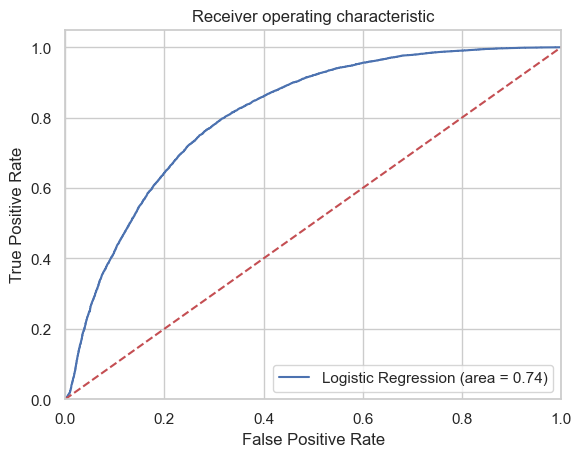

In [386]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()




#The dotted line represents the ROC curve of a purely random classifier; 
#a good classifier stays as far away from that line as possible 
#(toward the top-left corner)

Ländliche Regionen

In [166]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

df = pd.read_csv('MiD17_Final.csv')

#Filter für Stadt und Land
df_urban = df[df['Urban'] == 1]
df_rural = df[df['Rural'] ==1]


#RFE OUtput Feature: [False  True False  True False  True  True False False  True  True  True
#  True  True False  True False False False  True  True  True  True  True
#  True  True  True  True  True]
# Zielvariable definieren

features = [
    'Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp' ] # statistisch relevant durch z wer und verbessert durch P_Value um Multikorrealinität zu vermeiden
features2 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung',  
            'Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr','EcoStatusHigh', 'GraduationHigh','wegkm_imp']
#features2 = [
#    'Winter','Other_Transportation_Trip','PassengerOnBoard','IsMan','FamilienHaushalt',
#    'EcoStatusHigh', 'GraduationHigh','Distance_<2km', 'Time_<15min','Erwachsene[18-49]' ,
#    'Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung'] #Indikatoren
# statistisch relevant durch z wer und verbessert durch P_Value um Multikorrealinität zu vermeiden

#features1 = [
#    'Endbewertung','Rain_or_Snowfall', 'Winter','Work_Trip', 'Leisure_Trip', 'Time_<10min', 'Time_10-20min', 'Time_20-30min', 'Time_30-60min', 'Time_>60min',
#    'PassengerOnBoard', 'IsMan','EcoStatusHigh', 'GraduationHigh', 'JungerHaushaltU35','Alterab60Jahre',
#    'Distance_<0.5km', 'Distance_0.5-1km', 'Distance_1-2km', 'Distance_2-5km', 'Distance_5-10km',
#    ] #20 Stück gefiltert durch RFE TEST
#features12 = [
#    'Endbewertung','Rain_or_Snowfall','Winter','Leisure_Trip','Other_Transportation_Trip','Time_>60min', 'Time_<10min',
#    'PassengerOnBoard', 'IsMan','EcoStatusHigh', 'GraduationHigh','Alterab60Jahre', 'JungeErwachsene[18-29]',
#    'Distance_5-10km', 'Distance_<0.5km'
#    ] #verbessert durch P_Value um Multikorrealinität zu vermeiden
#features2 = ['Endbewertung','Rain_or_Snowfall']
#features3 = ['Work_Trip', 'Other_Transportation_Trip', 'Leisure_Trip'] #Zweck des Trips
#features4 = ['Distance_<0.5km', 'Distance_0.5-1km', 'Distance_1-2km', 'Distance_2-5km', 'Distance_5-10km'] #Distanzen
#features5 = ['JungeErwachsene[18-29]','Erwachsene[30-39]','Erwachsene[40-49]','Erwachsene[50-59]','Alterab60Jahre']  #Alter
#features6 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung'] #Indikatoren
features12 = ['Surface_Bewertung']
# Extraktion der Features und der Zielvariable aus dem DataFrame
X = df_rural[features]
y = df_rural['Mode_Choice_Combined']

# Importieren von SMOTE zur Behandlung von unausgewogenen Daten
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

# Aufteilen der Daten in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns

# Anwendung von SMOTE auf den Trainingsdatensatz zur Erzeugung eines ausgewogenen Datensatzes
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

#Konvertierung der oversampled Data in pd DataFrame
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Mode_Choice_Combined'])
# we can Check the numbers of our data
# Ausgabe der Länge und Zusammensetzung der oversampled Data
print("length of oversampled data is ",len(os_data_X))
print("Number of Car in oversampled data",len(os_data_y[os_data_y['Mode_Choice_Combined']==0]))
print("Number of Bici/Pedelec",len(os_data_y[os_data_y['Mode_Choice_Combined']==1]))
print("Proportion of Car in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Combined']==0])/len(os_data_X))
print("Proportion of Bici/Pedelec in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Combined']==1])/len(os_data_X))


X = os_data_X
y= os_data_y['Mode_Choice_Combined']
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())

length of oversampled data is  28696
Number of Car in oversampled data 14348
Number of Bici/Pedelec 14348
Proportion of Car in oversampled data is  0.5
Proportion of Bici/Pedelec in oversampled data is  0.5
Optimization terminated successfully.
         Current function value: 0.584313
         Iterations 6
                           Results: Logit
Model:              Logit                Method:           MLE       
Dependent Variable: Mode_Choice_Combined Pseudo R-squared: 0.157     
Date:               2024-03-14 14:46     AIC:              33552.8701
No. Observations:   28696                BIC:              33627.2508
Df Model:           8                    Log-Likelihood:   -16767.   
Df Residuals:       28687                LL-Null:          -19891.   
Converged:          1.0000               LLR p-value:      0.0000    
No. Iterations:     6.0000               Scale:            1.0000    
---------------------------------------------------------------------
                   

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

Accuracy

In [15]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.69


Ländliche Gegend Confusion Matrix

In [16]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[2776 1311]
 [1248 2877]]


Ländliche Gegend Compute precision, recall, F-measure and support


In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.68      0.68      4087
           1       0.69      0.70      0.69      4125

    accuracy                           0.69      8212
   macro avg       0.69      0.69      0.69      8212
weighted avg       0.69      0.69      0.69      8212



Ländliche Gegend (ROC-Kurve)

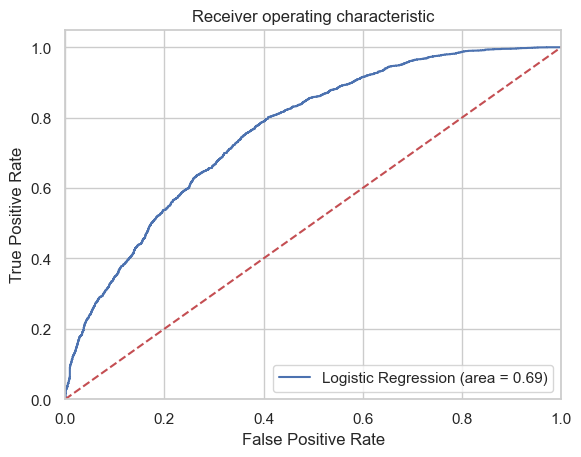

In [19]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()



Städtische Gegenden

In [168]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

df = pd.read_csv('MiD17_Final.csv')

#Filter für Stadt und Land
df_urban = df[df['Urban'] == 1]
df_rural = df[df['Rural'] ==1]

features = [
    'Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp' ] # statistisch relevant durch z wer und verbessert durch P_Value um Multikorrealinität zu vermeiden
features2 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung',  
            'Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp']
#features1 = [
#    'Endbewertung', 'Winter','Work_Trip', 'Leisure_Trip', 'Time_<10min', 'Time_10-20min', 'Time_20-30min', 'Time_30-60min', 'Time_>60min',
 #   'PassengerOnBoard', 'IsMan','EcoStatusHigh', 'GraduationHigh', 'JungerHaushaltU35','Alterab60Jahre',
#    'Distance_<0.5km', 'Distance_0.5-1km', 'Distance_1-2km', 'Distance_2-5km', 'Distance_5-10km',
#    ] #20 Stück gefiltert durch RFE TEST
#features12 = [
#    'Endbewertung','Rain_or_Snowfall','Winter','Leisure_Trip','Other_Transportation_Trip','Time_>60min', 'Time_<10min',
#    'PassengerOnBoard', 'IsMan','EcoStatusHigh', 'GraduationHigh','Alterab60Jahre', 'JungeErwachsene[18-29]',
#    'Distance_5-10km', 'Distance_<0.5km'
#    ] #verbessert durch P_Value um Multikorrealinität zu vermeiden
#features2 = ['Endbewertung','Rain_or_Snowfall']
#features3 = ['Work_Trip', 'Other_Transportation_Trip', 'Leisure_Trip'] #Zweck des Trips
#features4 = ['Distance_<0.5km', 'Distance_0.5-1km', 'Distance_1-2km', 'Distance_2-5km', 'Distance_5-10km'] #Distanzen
#features5 = ['JungeErwachsene[18-29]','Erwachsene[30-39]','Erwachsene[40-49]','Erwachsene[50-59]','Alterab60Jahre']  #Alter
#features6 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung'] #Indikatoren
features12 = ['Surface_Bewertung']
# Extraktion der Features und der Zielvariable aus dem DataFrame
X = df_urban[features]
y = df_urban['Mode_Choice_Combined']

# Importieren von SMOTE zur Behandlung von unausgewogenen Daten
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

# Aufteilen der Daten in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns

# Anwendung von SMOTE auf den Trainingsdatensatz zur Erzeugung eines ausgewogenen Datensatzes
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

#Konvertierung der oversampled Data in pd DataFrame
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Mode_Choice_Combined'])
# we can Check the numbers of our data
# Ausgabe der Länge und Zusammensetzung der oversampled Data
print("length of oversampled data is ",len(os_data_X))
print("Number of Car in oversampled data",len(os_data_y[os_data_y['Mode_Choice_Combined']==0]))
print("Number of Bici/Pedelec",len(os_data_y[os_data_y['Mode_Choice_Combined']==1]))
print("Proportion of Car in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Combined']==0])/len(os_data_X))
print("Proportion of Bici/Pedelec in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Combined']==1])/len(os_data_X))

X = os_data_X
y= os_data_y['Mode_Choice_Combined']
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())

length of oversampled data is  99222
Number of Car in oversampled data 49611
Number of Bici/Pedelec 49611
Proportion of Car in oversampled data is  0.5
Proportion of Bici/Pedelec in oversampled data is  0.5
Optimization terminated successfully.
         Current function value: 0.613541
         Iterations 5
                            Results: Logit
Model:              Logit                Method:           MLE        
Dependent Variable: Mode_Choice_Combined Pseudo R-squared: 0.115      
Date:               2024-03-14 14:50     AIC:              121771.4703
No. Observations:   99222                BIC:              121857.0164
Df Model:           8                    Log-Likelihood:   -60877.    
Df Residuals:       99213                LL-Null:          -68775.    
Converged:          1.0000               LLR p-value:      0.0000     
No. Iterations:     5.0000               Scale:            1.0000     
----------------------------------------------------------------------
         

Modell Fitting

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

Städtische Regionne Accuracy

In [22]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.67


Städtische Regione Confusion Matrix

In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[9502 4873]
 [4536 9705]]


Compute precision, recall, F-measure and support


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.66      0.67     14375
           1       0.67      0.68      0.67     14241

    accuracy                           0.67     28616
   macro avg       0.67      0.67      0.67     28616
weighted avg       0.67      0.67      0.67     28616



Städtische Regionen ROC_Kurve

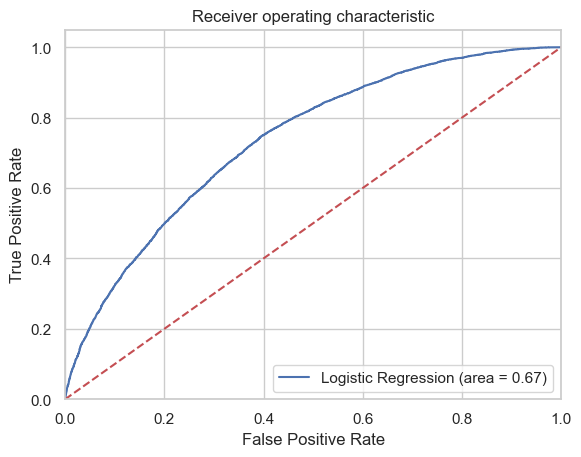

In [25]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()



E-Bike Steigung vs.
Fahrrad Steigung

Fahrrad

In [187]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

df = pd.read_csv('MiD17_Final.csv')

#Filter für Stadt und Land
df_urban = df[df['Urban'] == 1]
df_rural = df[df['Rural'] ==1]


#RFE OUtput Feature: [False  True False  True False  True  True False False  True  True  True
#  True  True False  True False False False  True  True  True  True  True
#  True  True  True  True  True]
# Zielvariable definieren
features = [
    'Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp' ] 
features0 = [
    'Winter','Other_Transportation_Trip','PassengerOnBoard','IsMan','FamilienHaushalt',
    'EcoStatusHigh', 'GraduationHigh','Distance_<2km', 'Time_<15min','Erwachsene[18-49]' ,'Endbewertung'] # statistisch relevant durch z wer und verbessert durch P_Value um Multikorrealinität zu vermeiden
features3 = ['Endbewertung','Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung']
features1 = ['Endbewertung', 'alter_gr','wegmin_imp1','wegkm_imp'] #Demografischer Vergleich
features5 = ['alter_gr']
# Extraktion der Features und der Zielvariable aus dem DataFrame
X = df[features]
y = df['Mode_Choice_Bici']

# Importieren von SMOTE zur Behandlung von unausgewogenen Daten
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

# Aufteilen der Daten in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns

# Anwendung von SMOTE auf den Trainingsdatensatz zur Erzeugung eines ausgewogenen Datensatzes
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

#Konvertierung der oversampled Data in pd DataFrame
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Mode_Choice_Bici'])
# we can Check the numbers of our data
# Ausgabe der Länge und Zusammensetzung der oversampled Data
print("length of oversampled data is ",len(os_data_X))
print("Number of NonBici in oversampled data",len(os_data_y[os_data_y['Mode_Choice_Bici']==0]))
print("Number of Bici",len(os_data_y[os_data_y['Mode_Choice_Bici']==1]))
print("Proportion of nonBici in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Bici']==0])/len(os_data_X))
print("Proportion of Bici/Pedelec in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Bici']==1])/len(os_data_X))

X = os_data_X
y= os_data_y['Mode_Choice_Bici']
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())

length of oversampled data is  131550
Number of NonBici in oversampled data 65775
Number of Bici 65775
Proportion of nonBici in oversampled data is  0.5
Proportion of Bici/Pedelec in oversampled data is  0.5
Optimization terminated successfully.
         Current function value: 0.601913
         Iterations 5
                           Results: Logit
Model:               Logit             Method:            MLE        
Dependent Variable:  Mode_Choice_Bici  Pseudo R-squared:  0.132      
Date:                2024-03-14 16:03  AIC:               158381.3035
No. Observations:    131550            BIC:               158469.3877
Df Model:            8                 Log-Likelihood:    -79182.    
Df Residuals:        131541            LL-Null:           -91184.    
Converged:           1.0000            LLR p-value:       0.0000     
No. Iterations:      5.0000            Scale:             1.0000     
---------------------------------------------------------------------
                  

Pedelec

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

df = pd.read_csv('MiD17_FinalPedelecvsCar.csv')

#Filter für Stadt und Land
df_urban = df[df['Urban'] == 1]
df_rural = df[df['Rural'] ==1]


#RFE OUtput Feature: [False  True False  True False  True  True False False  True  True  True
#  True  True False  True False False False  True  True  True  True  True
#  True  True  True  True  True]
# Zielvariable definieren
features = [
    'Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp' ] 
features2 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung',  
           'Winter', 'Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp']


features3 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung']
features12 = ['alter_gr']# Extraktion der Features und der Zielvariable aus dem DataFrame
X = df[features]
y = df['Mode_Choice_Pedelec']

# Importieren von SMOTE zur Behandlung von unausgewogenen Daten
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

# Aufteilen der Daten in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns

# Anwendung von SMOTE auf den Trainingsdatensatz zur Erzeugung eines ausgewogenen Datensatzes
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

#Konvertierung der oversampled Data in pd DataFrame
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Mode_Choice_Pedelec'])
# we can Check the numbers of our data
# Ausgabe der Länge und Zusammensetzung der oversampled Data
print("length of oversampled data is ",len(os_data_X))
print("Number of Car in oversampled data",len(os_data_y[os_data_y['Mode_Choice_Pedelec']==0]))
print("Number of Bici/Pedelec",len(os_data_y[os_data_y['Mode_Choice_Pedelec']==1]))
print("Proportion of Car in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Pedelec']==0])/len(os_data_X))
print("Proportion of Bici/Pedelec in oversampled data is ",len(os_data_y[os_data_y['Mode_Choice_Pedelec']==1])/len(os_data_X))

X = os_data_X
y= os_data_y['Mode_Choice_Pedelec']
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())

length of oversampled data is  13264
Number of Car in oversampled data 6632
Number of Bici/Pedelec 6632
Proportion of Car in oversampled data is  0.5
Proportion of Bici/Pedelec in oversampled data is  0.5
Optimization terminated successfully.
         Current function value: 0.630119
         Iterations 5
                           Results: Logit
Model:              Logit               Method:           MLE       
Dependent Variable: Mode_Choice_Pedelec Pseudo R-squared: 0.091     
Date:               2024-03-15 10:11    AIC:              16733.7959
No. Observations:   13264               BIC:              16801.2312
Df Model:           8                   Log-Likelihood:   -8357.9   
Df Residuals:       13255               LL-Null:          -9193.9   
Converged:          1.0000              LLR p-value:      0.0000    
No. Iterations:     5.0000              Scale:            1.0000    
--------------------------------------------------------------------
                     Coef.  St

Distanz auf Pedelec vs Bike

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

df = pd.read_csv('MiD17_FinalDistance.csv')

#Filter für Stadt und Land
df_urban = df[df['Urban'] == 1]
df_rural = df[df['Rural'] ==1]


#RFE OUtput Feature: [False  True False  True False  True  True False False  True  True  True
#  True  True False  True False False False  True  True  True  True  True
#  True  True  True  True  True]
# Zielvariable definieren
features = [
    'Endbewertung','Winter','Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh'] 
features2 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung',  
           'Winter', 'Rain_or_Snowfall','Transport/Work_Trip','IsMan','alter_gr',
    'EcoStatusHigh', 'GraduationHigh','wegkm_imp']


features3 = ['Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung']
features12 = ['alter_gr']# Extraktion der Features und der Zielvariable aus dem DataFrame
X = df[features]
y = df['Distance_5-10km']

# Importieren von SMOTE zur Behandlung von unausgewogenen Daten
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

# Aufteilen der Daten in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns

# Anwendung von SMOTE auf den Trainingsdatensatz zur Erzeugung eines ausgewogenen Datensatzes
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

#Konvertierung der oversampled Data in pd DataFrame
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Distance_5-10km'])
# we can Check the numbers of our data
# Ausgabe der Länge und Zusammensetzung der oversampled Data
print("length of oversampled data is ",len(os_data_X))
print("Number of Car in oversampled data",len(os_data_y[os_data_y['Distance_5-10km']==0]))
print("Number of Bici/Pedelec",len(os_data_y[os_data_y['Distance_5-10km']==1]))
print("Proportion of Car in oversampled data is ",len(os_data_y[os_data_y['Distance_5-10km']==0])/len(os_data_X))
print("Proportion of Bici/Pedelec in oversampled data is ",len(os_data_y[os_data_y['Distance_5-10km']==1])/len(os_data_X))

X = os_data_X
y= os_data_y['Distance_5-10km']
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())